# E5 - Capstone group assignment
## Due on 17 May 2026 (11:59 PM)

### Assignment context:

Putting all together
This exercise is meant to put together all the methods you have learned. The aim is to visualize remote-sensed ocean colour data from the ESA-CCI Ocean Colour climatology and perform a few computations. The data file contains the climatological monthly means of the satellite-derived chlorophyll concentration for the world ocean, with a very high spatial resolution (4 km). The file is quite big (1.7 GB).

Chlorophyll concentration is used as a proxy for phytoplankton biomass. Chlorophyll in the ocean spans a few order of magnitudes, from small concentrations lower than 0.2 mg Chl/m3 in the open ocean to values close to 100 in the eutrophic regions. The physical features of the ocean partly determine the climatological values of chlorophyll. Bathymetry is thus an important component to consider for phytoplankton development.

Bathymetry information are essential in oceanography. There are a few open source products on the web, besides the Natural Earth bathymetry shapefiles, which contains the bathymetric contours at a few selected depths.

The Global Multi-Resolution Topography Data Synthesis (GMRT) is a digital elevation map of the Earth that combines high resolution sounding data with the General Bathymetric Chart of the Ocean (GEBCO). The GEBCO dataset is very big, but still recommended as the reference chart. The GMRT provides a useful map application that allows to download data from a selected region in netCDF format. We want to download the netCDF format that follows the Climate&Forecast convention.

You will choose a rectangular coastal region of the world ocean, of your interest. The region should be about 200-300 km wide/long to take full advantage of the high resolution of the satellite data. 

### Assignment instructions:

1. Choose a name for your group (if you are an individual, use your UCT ID). 
2. Creating the GitHub repository called SAMOS2026-Core3CS-GROUPNAME. Any other member of the group will be added to the repository as collaborators to submit changes.
3. Download the bathymetry for the region of choice from the GMRT application. Make sure to use an adequate resolution, since the chlorophyll data are at 4 km resolution.
4. Write a (commented!) python notebook that produces the following output/figures:
4.1. A large figure with the map of the region bathymetry, using an adequate colormap
4.2. A map of the mean annual chlorophyll. Choose carefully the range of values and the colormap, to display the different regions (Note: chlorophyll is usually plotted in logarithmic scale)
4.3. A faceted figure, showing 12 maps, one for each month. The colorbar range can be different from the annual mean map, because it should show the seasonal variation.
4.4. A timeseries plot showing two lines: the mean seasonal cycle of the whole region compared with the timeseries from a single grid point of your choice, preferably close to an area of high chlorophyll
5. Submit a PDF containing 5 sections:
5.1. a brief introduction explaining your choice of the region.
5.2. a description of the datasets and the listings of the metadata (netcdf info) from the bathymetry and chlorophyll data files.
the requested figures, with a brief caption for each one.
5.3. a disclaimer about your use of AI. Include a description of how AI was used and some example of the prompts references.

### Answers:

1. 

In [1]:
# importing all my packages at the beginning of the script
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
from matplotlib.colors import LogNorm
from matplotlib.colors import BoundaryNorm
import seaborn as sns

In [2]:
# loading gridded data into notebook as a variable stored as grd.
grd_dat = xr.open_dataset("C:/Users/Mahlatse/Documents/AOS-SAMOS_2026-28/Python/SAMOS2026-Core3CS-MTBMAH005/gul-of-mexico_20260513_grid-file_GMT_Coards-CF-Compliant_244m-node_GMRT-v4.4.grd")   # ← replace with your filename
grd_dat

<xarray.Dataset> Size: 11MB
Dimensions:   (lat: 1181, lon: 1140)
Coordinates:
  * lat       (lat) float64 9kB 28.07 28.07 28.07 28.07 ... 30.33 30.33 30.33
  * lon       (lon) float64 9kB -90.95 -90.95 -90.95 ... -88.45 -88.45 -88.45
Data variables:
    altitude  (lat, lon) float64 11MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7

In [3]:
# to inspect the gridded data variables and then allocate the values of each variable to a local name (in the data its saved as altitude but i will be using negative values only thus bathymetry is my variable of interest not altitude). 
bathy = grd_dat['altitude'].values           
lon   = grd_dat['lon'].values          
lat   = grd_dat['lat'].values        
lon2d, lat2d = np.meshgrid(lon, lat)

In [4]:
# i noticed i had na values in my data, to minimise the effect of non-ideal values on my visualisation process I then mask negative and thus any positive values cause i only want the bathymetry values (sub-zero depths).
bathy_masked = np.ma.masked_greater(bathy, 0)

vmin = float(np.nanmin(bathy_masked))   # deepest point
vmax = 0                                # sea surface

In [5]:
# here i am setting up my colour map and using the hsv colour theme and then normalising the original bathymetric values against that required for python to create the colour bar.
cmap = plt.cm.cividis                
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

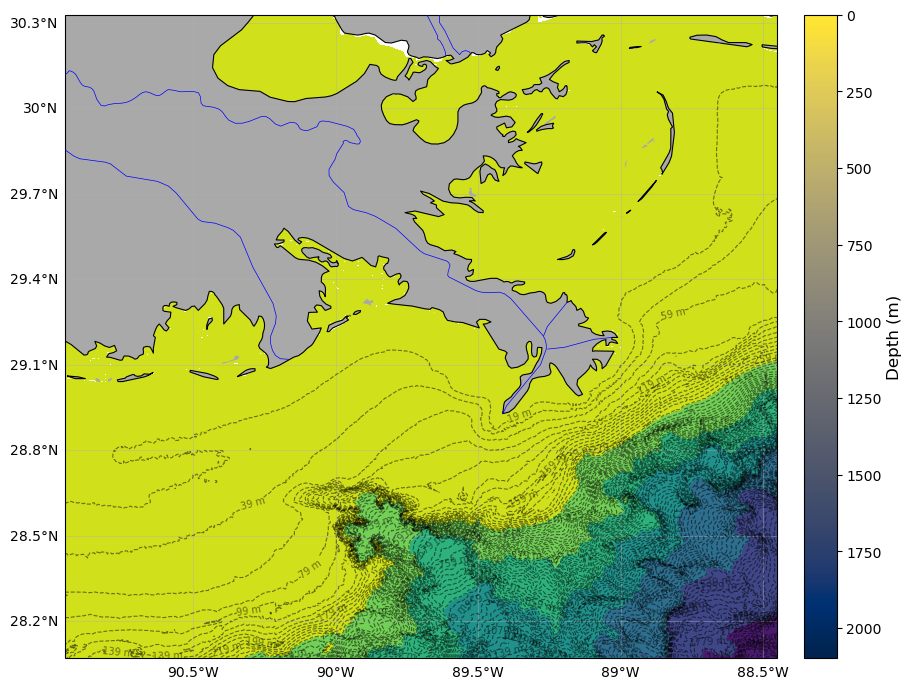

In [6]:
# setting up the extents of my map that i want to plot
central_lon, central_lat = -89.70, 29.20
extent = [-90.95, -88.45, 28.07, 30.33]            
data_crs = ccrs.PlateCarree()           # this choice is from the metadata saying the bathymetry data was in a cylindrical view. So i chose PlateCarree as the projection to use.

# setting up the plot and its axes that i want to create
fig, ax = plt.subplots(figsize=(14, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}  # EPSG:4326
)

ax.set_extent(extent, crs=data_crs)

mesh = ax.pcolormesh(
    lon2d, lat2d, bathy_masked,
    transform=data_crs,
    cmap=cmap,
    norm=norm,
    shading='auto',
    zorder=1
)

# setting up my contours 
contour_levels = np.arange(vmin, vmax, 20)   # contour every 50 m, because i realised that this shelf is quite shallow so to not underrepresent this dat i used the maximum depth of the contental shelf break.

contours = ax.contour(
    lon2d, lat2d, bathy_masked,
    levels=contour_levels,
    transform=data_crs,
    colors='black',
    linewidths=0.8,
    alpha=0.5,
    zorder=4
)

# labelling the contour lines i created by shared depth in m
ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt = lambda x: f'{abs(x):.0f} m',
    inline_spacing=5
)

# adding useful coastal and border features to my bathymetry plot
ax.coastlines(resolution='10m', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND, facecolor='darkgrey', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
ax.contourf(lon, lat, bathy_masked, transform=ccrs.PlateCarree())

# adding the Mississippi River & Delta to add some more context to my plot
mississippi = cfeature.NaturalEarthFeature(
    category='physical',
    name='rivers_lake_centerlines',
    scale='10m',
    facecolor='none',
    edgecolor='blue',
    linewidth=0.5
)
ax.add_feature(mississippi, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='-', alpha=0.6)
gl.right_labels = False
gl.top_labels   = False

# setting up the shared colour bar 
cbar = fig.colorbar(
    mesh,
    ax=ax,                  # attaches to both axes
    orientation='vertical',
    fraction=0.08,
    pad=0.02,
    shrink=1
)
cbar.set_label('Depth (m)', fontsize=12)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{abs(x):.0f}'))
plt.tight_layout()

plt.savefig('bathymetry_map.png', dpi=300, bbox_inches='tight')
plt.show()

2.

In [8]:
# importing the full chlorophyll dataset from my repository using xarray
full_chloro_dat = xr.open_dataset('full_chloro_data.nc')

In [9]:
# inspecting my dataset
full_chloro_dat

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [15]:
# setting my working extent. This extent is for the 250 by 250 km area over the mississippi delta. 
lat_min = 28.068103
lat_max = 30.331161
lon_min = -90.951416
lon_max = -88.448730

extent = [lon_min, lon_max, lat_min, lat_max]

# the following code then tells python to extract the chlorophyll-a data that are bounded within the given latitudes and longitudes and drop na values.
mississippi_subset = full_chloro_dat.where(
    (full_chloro_dat["lat"] >= lat_min) &
    (full_chloro_dat["lat"] <= lat_max) &
    (full_chloro_dat["lon"] >= lon_min) &
    (full_chloro_dat["lon"] <= lon_max),
    drop=True
)

In [13]:
# updating the subsetted mississippi data by assigning a logarithmic calculation on all the values collected from the area.
mississippi_subset = mississippi_subset.assign(
    log_chlor_a=np.log10(mississippi_subset["chlor_a"] + 1e-6)
)

In [14]:
# here I went about calculating the annual mean in the log transformed chlorophyll-a dataset against time variable.
annual_mean = mississippi_subset["log_chlor_a"].mean(dim="time")

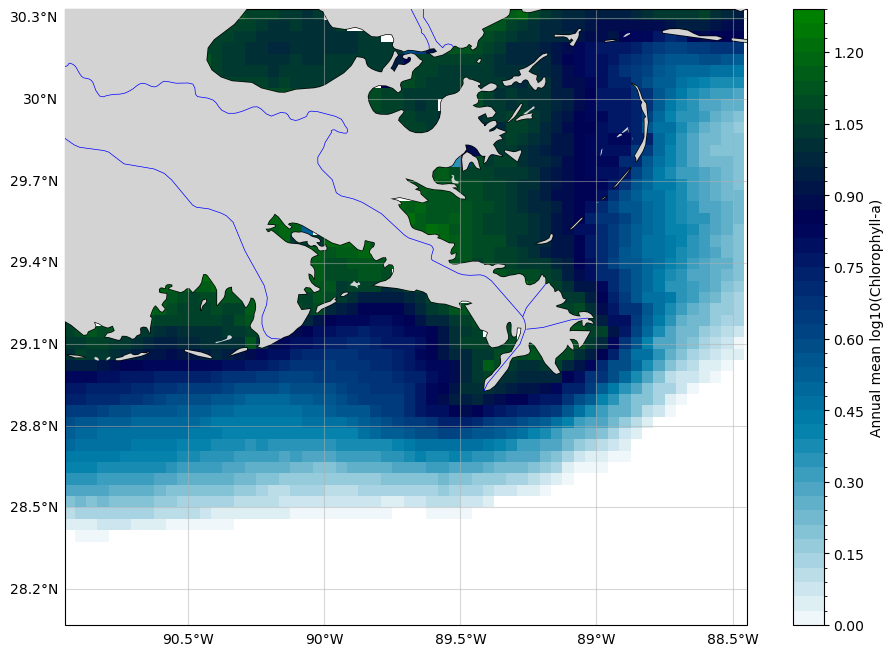

In [37]:
# setting up the figure and the axes i will be plotting on.
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# setting the map window
ax.set_extent(extent, crs=ccrs.PlateCarree())

# to get my maximum chlorophyll value u calculate the following
vmax = float(annual_mean.max().values)
# 1.2874295711517334

# creating the main plot
img = annual_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="ocean_r",
    vmin=0,
    vmax=vmax,
    levels=np.arange(0, 1.3, 0.03),
    zorder=1,
    cbar_kwargs={
        "label": "Annual mean log10(Chlorophyll-a)",
        "extend": "neither"
    }
)

# adding the features i want on my map
ax.coastlines(resolution="10m", linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=4)

# adding the Mississippi River & Delta to add some more context to my plot
mississippi = cfeature.NaturalEarthFeature(
    category='physical',
    name='rivers_lake_centerlines',
    scale='10m',
    facecolor='none',
    edgecolor='blue',
    linewidth=0.5
)
ax.add_feature(mississippi, zorder=5)

# adding the grids i want to overlay
gl = ax.gridlines(draw_labels=True, linestyle="-", alpha=0.5)
gl.right_labels = False
gl.top_labels = False

plt.savefig('mean annual chlorophyll a log scale.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# re-establishing the variable with the log transformed data for the mississippi subsetted data from the whole dataset.
log_chlor_a=np.log10(mississippi_subset["chlor_a"])
log_chlor_a

<xarray.DataArray 'chlor_a' (time: 12, lat: 54, lon: 60)> Size: 156kB
array([[[        nan,         nan,         nan, ...,  0.9421446 ,
          0.912275  ,  0.88650155],
        [        nan,         nan,         nan, ...,  0.87200475,
          0.8456258 ,  0.8458445 ],
        [        nan,         nan,         nan, ...,  0.8352647 ,
          0.8352647 ,  0.82113945],
        ...,
        [-0.1970815 , -0.2012296 , -0.1832807 , ..., -0.5068134 ,
         -0.50533974, -0.50533974],
        [-0.24392937, -0.24125162, -0.26888818, ..., -0.51634645,
         -0.5113242 , -0.51411813],
        [-0.3329529 , -0.33312753, -0.34477922, ..., -0.52355576,
         -0.5288899 , -0.5275436 ]],

       [[        nan,         nan,         nan, ...,  0.9532539 ,
          0.9079294 ,  0.8905815 ],
        [        nan,         nan,         nan, ...,  0.8753596 ,
          0.84765446,  0.8427923 ],
        [        nan,         nan,         nan, ...,  0.82811886,
          0.82811886,  0.8324192 ],
...
        [-0.46837214, -0.46806914, -0.43632928, ..., -0.684433  ,
         -0.68392783, -0.68392783],
        [-0.50665516, -0.5007515 , -0.49411577, ..., -0.69360816,
         -0.7057402 , -0.68918085],
        [-0.5384334 , -0.5123909 , -0.53121686, ..., -0.6788289 ,
         -0.6713177 , -0.6781136 ]],

       [[        nan,         nan,         nan, ...,  0.9054866 ,
          0.86111945,  0.8344071 ],
        [        nan,         nan,         nan, ...,  0.82449377,
          0.79522103,  0.79176474],
        [        nan,         nan,         nan, ...,  0.78100795,
          0.78100795,  0.7677101 ],
        ...,
        [-0.31736186, -0.33051807, -0.29888695, ..., -0.5956562 ,
         -0.5919604 , -0.5919604 ],
        [-0.3738067 , -0.37898037, -0.3911452 , ..., -0.6061876 ,
         -0.60381603, -0.58701444],
        [-0.41646633, -0.42356998, -0.42494076, ..., -0.6122832 ,
         -0.6285259 , -0.62234986]]], shape=(12, 54, 60), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 432B 30.31 30.27 30.23 30.19 ... 28.19 28.15 28.1
  * lon      (lon) float64 480B -90.94 -90.9 -90.85 ... -88.56 -88.52 -88.48
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [41]:
# searching for the highest log transformed chorophyll-a value
log_chlor_a.max()
# 1.80174196

<xarray.DataArray 'chlor_a' ()> Size: 8B
array(1.80174196)
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

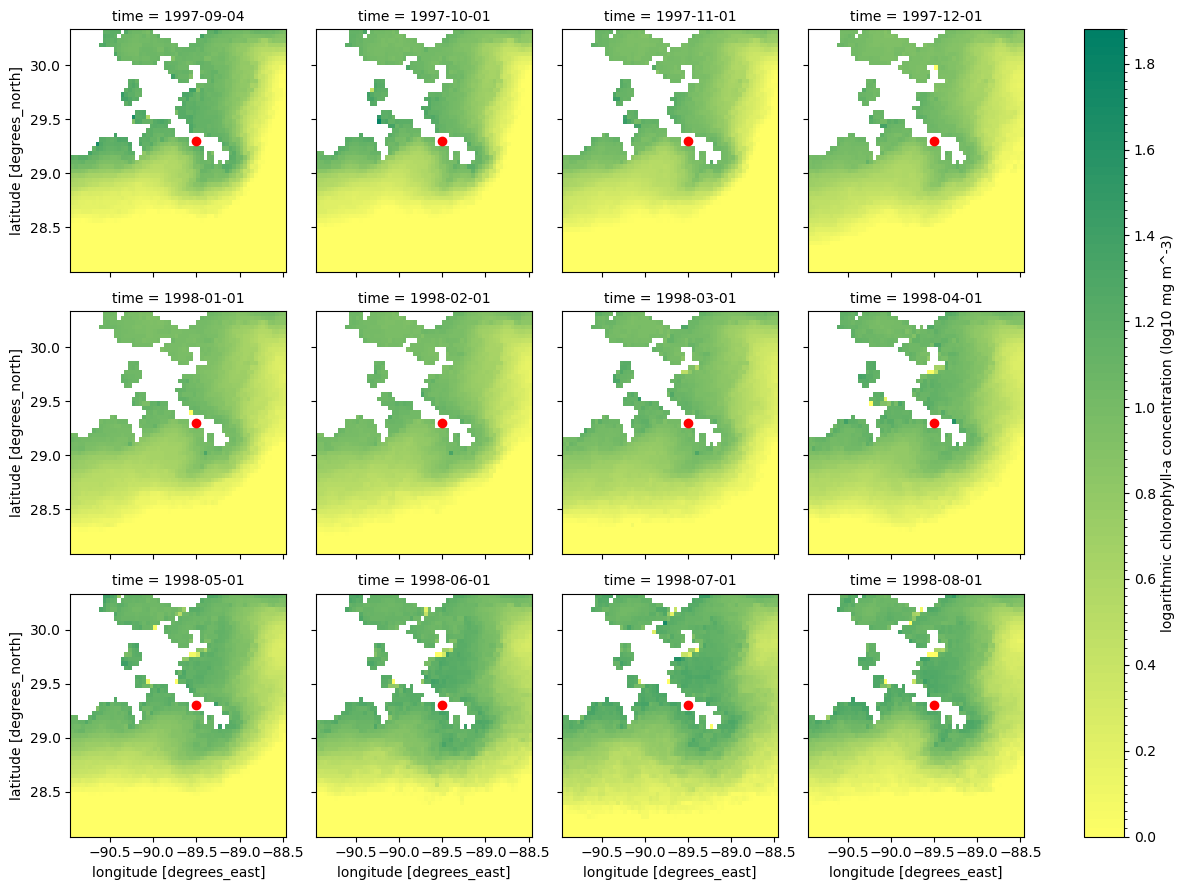

In [60]:
# plotting the average chlorophyll-a concentration across the surface of the ocean system above the Mississippi Delta for every month of measurement.

g = log_chlor_a.plot(
    col='time',
    col_wrap=4,
    cmap='summer_r',
    vmin=0,
    vmax=1.9,
    levels=np.arange(0, 1.9, 0.02),
    cbar_kwargs={
        'label': 'logarithmic chlorophyll-a concentration (log10 mg m^-3)',
        'extend': 'neither'
    },
    zorder=1
)

# to add the coordinates of my point of interest on my plots
lon = -89.5
lat = 29.3

# Add point to every subplot
for ax in g.axs.flat:
    
    ax.plot(
        lon,
        lat,
        marker='o',
        color='red',
        markersize=6,
        zorder=5
    )

plt.savefig('monthly averages of log chlorophyll_a values along mississippi.png', dpi=300, bbox_inches='tight')


In [51]:
# To get my lats and longs of maximum chlorophyll-a conc. i ran the following code i asked Claude to help me generate and it gave me a list of them and I just picked randomly.

max_idx = log_chlor_a.argmax(dim=['lat','lon'])

lat_point = log_chlor_a['lat'][max_idx['lat']]
lon_point = log_chlor_a['lon'][max_idx['lon']]

print(lat_point.values,lon_point.values)

[29.02083333 29.02083333 29.52083333 29.3125     29.10416667 29.10416667
 30.0625     30.3125     29.27083333 29.47916667 29.47916667 29.4375    ] [-89.39583333 -89.39583333 -90.0625     -89.27083333 -89.22916667
 -89.22916667 -89.77083333 -89.27083333 -90.64583333 -90.22916667
 -90.22916667 -90.10416667]


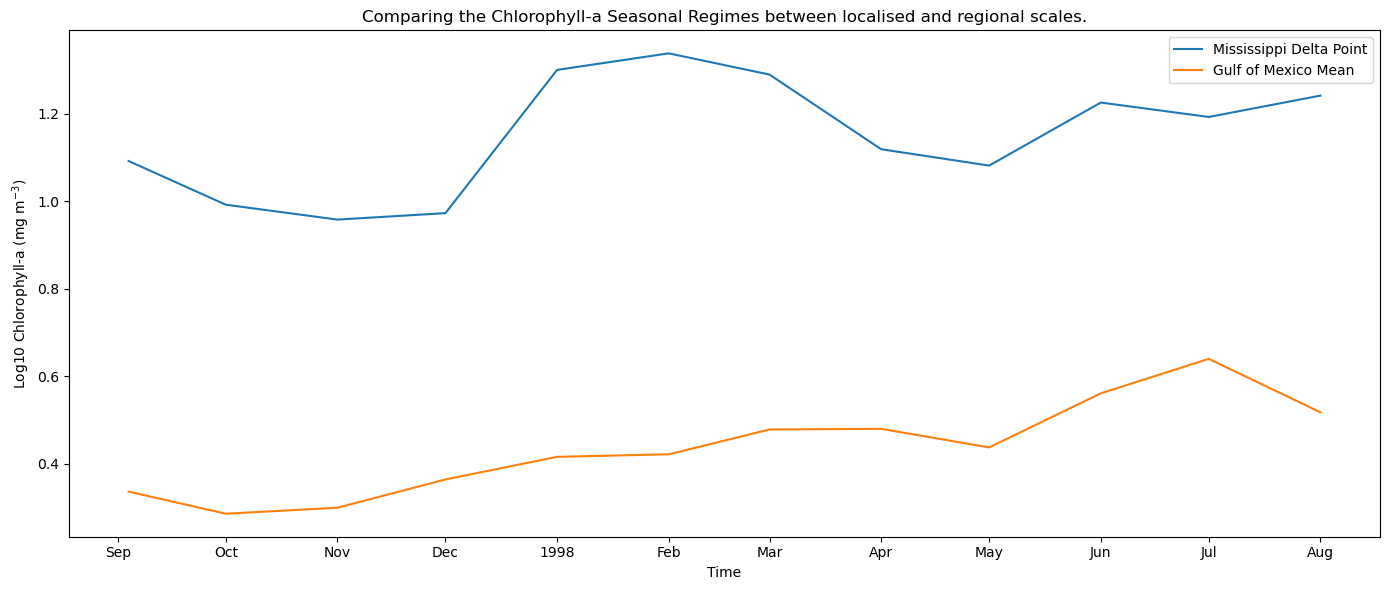

In [57]:
# log transforming my chlorophyll-a data from the subsetted area of interest and making my variable to house that only to then sort that data in ascending order by time.
log_chlor_a = np.log10(area_subset["chlor_a"])
log_chlor_a = log_chlor_a.sortby("time")

# point of high chlorophyll-a concentration selected and then the regional mean was calculated as per the coordinates given.
point = log_chlor_a.sel(lat=29.02083333, lon=-89.39583333, method="nearest")
region_mean = log_chlor_a.mean(dim=["lat", "lon"])

# this then converts my time column into the required format for python to interpret and sort them.
times = pd.to_datetime(log_chlor_a["time"].values)

# here i just set up my figure and the axes that will occupy the figure of the size dimensions given.
fig, ax = plt.subplots(figsize=(14,6))

# here i wanted to then plot my point of interests averages against that of the region of interest. I also labelled the lines accordingly for me to then use in the next line of code.
point.plot(ax=ax, label="Mississippi Delta Point")
region_mean.plot(ax=ax, label="Gulf of Mexico Mean")

# here i set the legend on my plot for the two trendlines
ax.legend()
ax.set_ylabel("Log10 Chlorophyll-a (mg m$^{-3}$)")
ax.set_xlabel("Time")
ax.set_title("Comparing the Chlorophyll-a Seasonal Regimes between localised and regional scales.")

plt.tight_layout()
plt.savefig('timeseries plot for point and region in chlorophyll_a.png', dpi=300, bbox_inches='tight')
plt.show()

### Bibliography:

Sathyendranath, S, Brewin, RJW, Brockmann, C, Brotas, V, Calton, B, Chuprin, A, Cipollini, P, Couto, AB, Dingle, J, Doerffer, R, Donlon, C, Dowell, M, Farman, A, Grant, M, Groom, S, Horseman, A, Jackson, T, Krasemann, H, Lavender, S, Martinez-Vicente, V, Mazeran, C, Mélin, F, Moore, TS, Müller, D, Regner, P, Roy, S, Steele, CJ, Steinmetz, F, Swinton, J, Taberner, M, Thompson, A, Valente, A, Zühlke, M, Brando, VE, Feng, H, Feldman, G, Franz, BA, Frouin, R, Gould, Jr., RW, Hooker, SB, Kahru, M, Kratzer, S, Mitchell, BG, Muller-Karger, F, Sosik, HM, Voss, KJ, Werdell, J, and Platt, T (2019) An ocean-colour time series for use in climate studies: the experience of the Ocean-Colour Climate Change Initiative (OC-CCI). Sensors: 19, 4285. doi:10.3390/s19194285

Sathyendranath, S.; Jackson, T.; Brockmann, C.; Brotas, V.; Calton, B.; Chuprin, A.; Clements, O.; Cipollini, P.; Danne, O.; Dingle, J.; Donlon, C.; Grant, M.; Groom, S.; Krasemann, H.; Lavender, S.; Mazeran, C.; Mélin, F.; Müller, D.; Steinmetz, F.; Valente, A.; Zühlke, M.; Feldman, G.; Franz, B.; Frouin, R.; Werdell, J.; Platt, T. (2023): ESA Ocean Colour Climate Change Initiative (Ocean_Colour_cci): Monthly climatology of global ocean colour data products at 4km resolution, Version 6.0. NERC EDS Centre for Environmental Data Analysis, date of citation. https://catalogue.ceda.ac.uk/uuid/690fdf8f229c4d04a2aa68de67beb733/. [13/05/2026]

Ryan, W.B.F., S.M. Carbotte, J.O. Coplan, S. O'Hara, A. Melkonian, R. Arko, R.A. Weissel, V. Ferrini, A. Goodwillie, F. Nitsche, J. Bonczkowski, and R. Zemsky (2009), Global Multi-Resolution Topography synthesis, Geochem. Geophys. Geosyst., 10, Q03014, doi: 10.1029/2008GC002332